In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install

In [2]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-yarnnuvk
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-yarnnuvk
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-20zvti94
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-20zvti94
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=0546648557b0b7e7dd1fc9255cdf598a447e84b9a47fed4ba2a217902c444957
  Stored in directory: /tmp/pip-ephem-wheel-cache-qdk27ww8/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything


In [4]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2025-03-24 10:13:10--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.33.183.121, 13.33.183.33, 13.33.183.29, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.33.183.121|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   106MB/s    in 24s     

2025-03-24 10:13:34 (103 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



##Import

In [13]:
import torch
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import ImageOps

import cv2
from segment_anything import sam_model_registry, SamPredictor
from diffusers import StableDiffusionInpaintPipeline

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

##Model

In [30]:
model, preprocess = clip.load("ViT-B/32", device=device)

In [18]:
ckpt_path = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=ckpt_path)
sam.to(device)
predictor = SamPredictor(sam)

In [21]:
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",  # Hugging Face 인페인팅 모델
    torch_dtype=torch.float16
).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


##Input

In [339]:
image_path = "/content/drive/MyDrive/URP/images/bowler.jpeg"
prompt = "batter and bowler"
target_prompt = "a batter and a bowler"

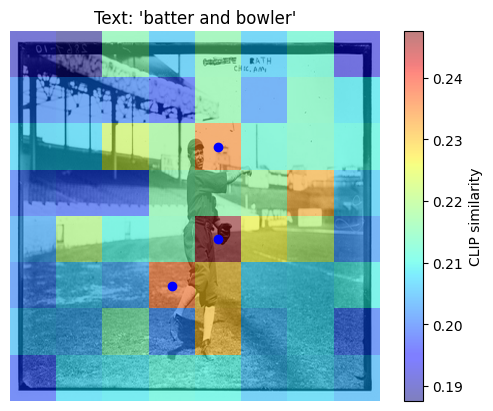

In [326]:
image = Image.open(image_path).convert("RGB").resize((512,512))
text = clip.tokenize([prompt]).to(device)

patch_size = 64
stride = 64

image_np = np.array(image)
h, w, _ = image_np.shape

heatmap = np.zeros((h // stride, w // stride))

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                std=(0.26862954, 0.26130258, 0.27577711)),
])

similarities = []
for i in range(0, h, stride):
    for j in range(0, w, stride):
        patch = image.crop((j, i, j + patch_size, i + patch_size))
        patch_input = transform(patch).unsqueeze(0).to(device)

        with torch.no_grad():
            image_feat = model.encode_image(patch_input)
            text_feat = model.encode_text(text)

            image_feat /= image_feat.norm(dim=-1, keepdim=True)
            text_feat /= text_feat.norm(dim=-1, keepdim=True)

            similarity = (image_feat @ text_feat.T).item()
            similarities.append((i, j, similarity))
            heatmap[i // stride, j // stride] = similarity

similarities.sort(key=lambda x: x[2], reverse=True)
points = []
sim_val = [x[2] for x in similarities]
threshold = (np.sum(sim_val)/len(sim_val))*(0.99)

for i in range(3):
  if similarities[i][2] < threshold:
    break
  points.append((similarities[i][1] + patch_size/2, similarities[i][0] + patch_size/2))

# 시각화
# plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.imshow(heatmap, cmap='jet', alpha=0.5, extent=[0, w, h, 0])
plt.plot([p[0] for p in points], [p[1] for p in points], 'bo')
plt.title(f"Text: '{prompt}'")
plt.axis("off")
plt.colorbar(label="CLIP similarity")
# plt.savefig(f"heatmap.png")
plt.show()

In [327]:
threshold

np.float64(0.20801239013671874)

In [328]:
predictor.set_image(np.array(image))

input_points = np.array(points)
input_labels = np.array([1]*len(points))

masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True,
)

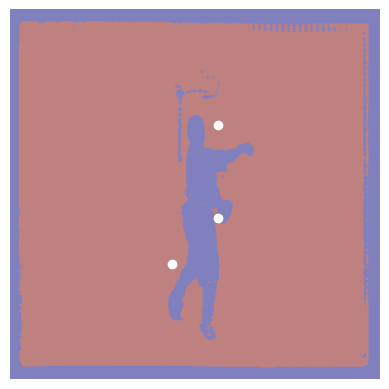

In [329]:
plt.imshow(masks[np.argmax(scores)], alpha=0.5, cmap='jet')

for (x, y) in points:
    plt.plot(x, y, 'wo')  # 흰색 포인트

plt.axis("off")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

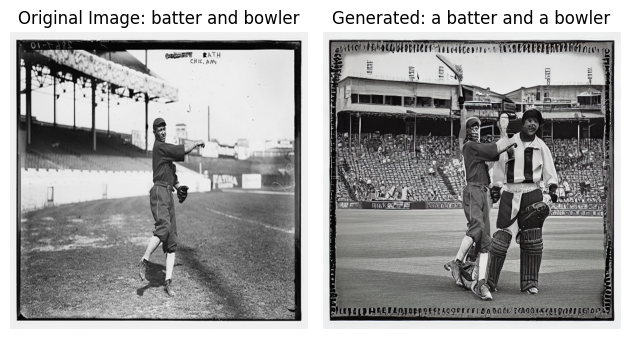

In [340]:
image = image
mask = Image.fromarray(masks[np.argmax(scores)])
# mask = ImageOps.invert(mask)
target_prompt = target_prompt

output = pipe(
    prompt=target_prompt,
    image=image,
    mask_image=mask
    # guidance_scale=,
    # num_inference_steps=,
).images[0]

result_image = output
# result_image.save("output.png")
# print("Image saved as output.png")

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original Image: {prompt}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_image)
plt.title(f"Generated: {target_prompt}")
plt.axis("off")

plt.tight_layout()
image_name = image_path.split('/')[-1].split('.')[0]
save_path = f"/content/drive/MyDrive/URP/result/demo/{image_name}_output_{target_prompt}.png"
plt.savefig(save_path)
plt.show()

#with diffedit

In [331]:
# import torch
# import torch.nn.functional as F

# def dilate_mask_torch(mask_tensor, kernel_size=5):
#     kernel = torch.ones((1, 1, kernel_size, kernel_size), device=device)
#     padding = kernel_size // 2

#     # Dilation = max pooling의 반대라고 생각하면 됨
#     dilated = F.conv2d(mask_tensor, kernel, padding=padding)
#     dilated = (dilated > 0).float()

#     return dilated

In [332]:
# image_path = "/content/drive/MyDrive/URP/images/green_apples.jpeg"
# image = Image.open(image_path).convert("RGB")

In [333]:
# import torch.nn.functional as F

# mask = masks[np.argmax(scores)]

# assert mask.shape[0] == image.size[1] and mask.shape[1] == image.size[0]

# h, w = mask.shape
# h, w = (x - x % 8 for x in (h, w))

# mask = 1-mask
# mask_tensor = torch.Tensor(mask).float().unsqueeze(0).unsqueeze(0)  # shape: (1, 1, H, W)
# mask_tensor = F.interpolate(mask_tensor, size=(h, w), mode='bilinear')
# scale_factor = 1 / 8
# latent_size = (int(h * scale_factor), int(w * scale_factor))
# mask_latent = F.interpolate(mask_tensor, size=latent_size, mode='bilinear', align_corners=True).to(device)
# mask_latent = dilate_mask_torch(mask_latent, kernel_size=5)
# mask_image = (mask_latent > 0.5).float()

In [334]:
# plt.imshow(mask_image.squeeze(0).squeeze(0).detach().cpu().numpy())

In [335]:
# import torch
# from PIL import Image
# import numpy as np
# import matplotlib.pyplot as plt
# import torchvision.transforms as T


# device = "cuda" if torch.cuda.is_available() else "cpu"

# image_path = "/content/drive/MyDrive/URP/images/green_apples.jpeg"
# image = Image.open(image_path).convert("RGB")

# # Define text prompt
# prompt = "apple"

In [336]:
# import PIL
# import requests
# import torch
# from io import BytesIO

# from diffusers import StableDiffusionDiffEditPipeline
# from diffusers import DDIMInverseScheduler, DDIMScheduler


# # pipeline = StableDiffusionDiffEditPipeline.from_pretrained(
# #     "stabilityai/stable-diffusion-2-1", torch_dtype=torch.float16
# # )
# pipeline = StableDiffusionDiffEditPipeline.from_pretrained(
#     "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
# )

# pipeline.scheduler = DDIMScheduler.from_config(pipeline.scheduler.config)
# pipeline.inverse_scheduler = DDIMInverseScheduler.from_config(pipeline.scheduler.config)
# pipeline.enable_model_cpu_offload()

In [337]:
# source_prompt = prompt
# target_prompt = "tennis ball"

# # mask_image = pipeline.generate_mask(image=image, source_prompt=prompt, target_prompt=mask_prompt)
# image_latents = pipeline.invert(image=image, prompt=target_prompt).latents
# generated_image = pipeline(
#     prompt=target_prompt,
#     mask_image=mask_image,
#     image_latents=image_latents).images[0]

In [338]:
# import matplotlib.pyplot as plt

# # Save results
# result_image = generated_image
# result_image.save("output.png")
# print("Image saved as output.png")

# # Display images
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.imshow(image)
# plt.title(f"Original Image: {source_prompt}")
# plt.axis("off")

# plt.subplot(1, 2, 2)
# plt.imshow(result_image)
# plt.title(f"Generated: {target_prompt}")
# plt.axis("off")

# plt.tight_layout()
# plt.savefig("output2.png")
# plt.show()